In [2]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 1. 生成数据集

In [3]:
def synthetic_data(w, b, num_exemples): #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_exemples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [4]:
print('features:', features[0], '\nlabel:', labels[0])


features: tensor([ 0.8334, -0.8530]) 
label: tensor([8.7641])


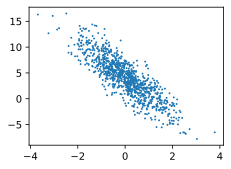

In [5]:
#通过生成第二个特征features[:, 1]和labels的散点图， 可以直观观察到两者之间的线性关系。
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(), labels.detach().numpy(), 1)

### 2. 读取数据集

In [6]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    #这些样本是随机读取的，没有特定的规律
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [7]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.6398,  0.1629],
        [ 0.5176,  1.8920],
        [-1.6137, -0.4495],
        [ 0.3070, -0.7278],
        [ 0.4608, -0.0799],
        [-0.8044,  1.5742],
        [ 0.7277,  1.3618],
        [ 0.4981, -0.1627],
        [ 0.2710,  1.4943],
        [-0.5205, -0.8430]]) 
 tensor([[ 2.3767],
        [-1.1979],
        [ 2.4881],
        [ 7.2812],
        [ 5.3929],
        [-2.7832],
        [ 1.0269],
        [ 5.7537],
        [-0.3565],
        [ 6.0315]])


### 3. 初始化参数模型

In [8]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

### 4. 定义模型

In [9]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

### 5. 定义损失函数

In [10]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### 6. 定义优化算法

In [11]:
def sgd(params, lr, batch_size):
    """小批量梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 7. 训练

In [12]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch{epoch + 1}, loss{float(train_l.mean()):f}')

epoch1, loss0.042330
epoch2, loss0.000155
epoch3, loss0.000050


In [13]:
print(f'w的估计误差：{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b - b}')


w的估计误差：tensor([ 8.5354e-05, -5.7650e-04], grad_fn=<SubBackward0>)
b的估计误差：tensor([0.0004], grad_fn=<RsubBackward1>)


### 练习

In [14]:
# 1. 生成数据集
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1 , size=(num_examples, len(w))) # X 是随机正态分布，shape = (num_examples, len(w))
    y = torch.matmul(X, w) + b # y = Xw + b，然后加噪声
    y += torch.normal(0, 0.01, size=y.shape)# 返回 X 和 y.reshape(-1, 1)
    return X, y.reshape(-1, 1)

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

# 2. 读取数据集
def data_iter(batch_size, features, labels):
    # 打乱索引，按 batch 返回数据
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# 3. 初始化参数
w = torch.normal(0, 0.01, size= (2, 1), requires_grad=True) # 正态分布，shape=(2,1)，requires_grad=True
b = torch.zeros(1, requires_grad=True) # 全0，shape=(1,)，requires_grad=True

# 4. 定义模型
def linreg(X, w, b):
    # 矩阵乘法 + 偏置
    return torch.matmul(X,w) + b

# 5. 定义损失函数
def squared_loss(y_hat, y):
    # 均方误差，注意 reshape
    return(y_hat - y.reshape(y_hat.shape)) ** 2 / 2

# 6. 定义优化器
def sgd(params, lr, batch_size):
    # 用 no_grad 更新参数，清零梯度
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 7. 训练循环
lr = 0.03
num_epochs = 3
batch_size = 10

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # 算 loss → backward → sgd 更新
        l = squared_loss(linreg(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    # 打印当前 epoch 的 loss
    with torch.no_grad():
        train_l = squared_loss(linreg(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

# 8. 打印误差
print(true_w - w.reshape(true_w.shape))
print(true_b - b)

epoch 1, loss 0.030068


epoch 2, loss 0.000109
epoch 3, loss 0.000052
tensor([0.0006, 0.0003], grad_fn=<SubBackward0>)
tensor([0.0008], grad_fn=<RsubBackward1>)
